
# Notebook 3: classificazione con 0-1 loss, minimi quadrati e regressione logistica

**Corso:** Introduzione alla Data Science e al Machine Learning

**Docenti:** Luca Calatroni, Lorenzo Rosasco

**Assignment:** Gli studenti completino le parti segnate con `#TO DO`.

## Goals
L'obiettivo del notebook è:
1. capire le difficoltà nella minimizzazione della **misclassification loss** (0-1);
2. usare i **minimi quadrati** per costruire un classificatore lineare in 1D;
3. implementare la **regressione logistica** con **gradient descent** per un classificatore lineare;
5. ragionare sulla scelta del **step-size** `gamma`.



---

## 0. Setup

Eseguite la seguente cella. Fissiamo il random seed e alcune impostazioni grafiche.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


## 1. Dataset 1D per classificazione binaria

Consideriamo dati della forma $(x_i, y_i)$. Nello spirito di un problema di classificazione $x_i\in\mathbb{R}$ rappresenta una caratteristica (feature) mentre $y_i \in \{-1,+1\}$ un'etichetta binaria (es., cane/gatto).

Nel seguito generiamo un dataset semplice ma non perfettamente separabile (come spesso avviene nella pratica): i punti con input positivi tendono ad avere etichetta $+1$, ma c'è rumore e dunque la separazione non è perfetta.


In [2]:
# Generate samples

n = 500
X = rng.normal(loc=0.0, scale=1.0, size=n)
sigma=0.6
noise = sigma * rng.normal(size=n)
Y = np.where(X + noise >= 0, 1, -1)

print("Numero di punti:", n)
print("Prime 10 feature:", np.round(X[:10], 3))
print("Prime 10 label:", Y[:10])


Numero di punti: 500
Prime 10 feature: [ 1.00e-03  2.99e-01 -2.74e-01 -8.91e-01 -4.55e-01 -9.92e-01  6.00e-02
  1.34e+00 -4.92e-01 -6.20e-01]
Prime 10 label: [-1 -1 -1 -1  1 -1 -1  1 -1 -1]


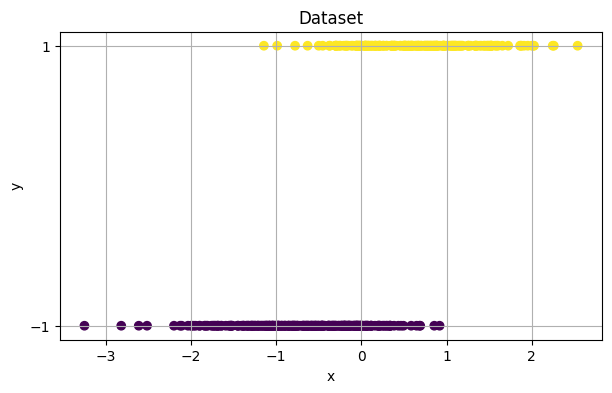

In [3]:
# Rappresentiamo i dati in un plot appropriato: sulle ascisse, le caratteristiche x, sulle ordinate (solo due valori possibili: +1 e -1 le corrispondenti etichette)

plt.scatter(X, Y, c=Y)
plt.yticks([-1, 1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset")
plt.show()



### Domande:

Guardando il grafico, rispondete:
- esiste una relazione tra il segno di $x$ e la corrispondente label $y$?
- il dataset sembra perfettamente separabile?


### Risposte:

Si può notare una relazione tra il segno di x e la corrispondenza di y:

- Quando x>0, i punti sembrano prevalentemente y=1 (gialli)
- uando x<0, i punti sembrano prevalentemente y=-1 (viola)

Però ci sono molte eccezioni in entrambe le direzioni, quindi la relazione esiste, ma è rumorosa.

Il dataset non è perfettamente separabile linearmente:
- Ci sono punti viola (y=-1) anche con x>0
- Ci sono punti gialli (y=1) anche con x<0
- Non esiste una soglia su x che separi perfettamente le due classi

Questo significa che nessun classifictore lineare (tipo una semplice soglia su x) riuscirebbe ad avere accuracy del 100% su questo dataset.

## 2. Rischio empirico con loss 0--1

Cerchiamo di definire un classificatore $f: \mathcal{X}\to \left\{+1,-1\right\}$. La loss 'naturale' di misclassificazione e il corrispondente problema di rischio empirico è
$$
\ell(y, f(x)) = \mathbf 1_{\{y \neq f(x)\}},\qquad \min_{f} ~\widehat{R}(f):=\frac{1}{n} \sum_{i=1}^n\ell(y_i, f(x_i))
$$

Il corrispondente classificatore ottimale (non-parametrico) è, per ogni $x\in\mathcal{X}$:

$$
f^*(x)= \begin{cases}
+1\quad&\quad \text{se}\quad p(Y=+1|x)>p(Y=-1|x)\\
-1\quad&\quad \text{altrimenti}.
\end{cases}
$$

In questo esercizio conosciamo il meccanismo generativo dei dati $Y$ (caso ideale, di solito questo *non* accade)
$$
Y = \mathrm{sign}(X+\varepsilon),\qquad \varepsilon \sim \mathcal N(0,\sigma^2), \quad \sigma=0.6.
$$

Quindi possiamo calcolare direttamente:
- $p(Y=+1\mid x)$
- $p(Y=-1\mid x)=1-p(Y=+1\mid x)$

E definire il classificatore secondo la regola di cui sopra.

Nel modello $ Y = \operatorname{sign}(X + \varepsilon) $, per calcolare 
$ p(Y = +1 \mid X = x) $ notiamo:

$$
p(Y = +1 \mid X = x) = p(x + \varepsilon > 0) = p(\varepsilon > -x),\qquad\text{(**)}
$$

Questa quantità dipende unicamente dalla distribuzione del rumore $ \varepsilon $, e non da quella di $ X $. Indicando con $ F_{\varepsilon} $ la funzione di ripartizione (CDF) di $ \varepsilon $, si può scrivere
$$
p(Y = +1 \mid X = x) = 1 - F_{\varepsilon}(-x),
$$
che, vista la distribuzione del rumore, allora
$$
p(Y = +1 \mid X = x) = \Phi\!\left(\frac{x}{\sigma}\right),
$$
dove $ \Phi $ è la CDF della normale standard con formula:
$$
\Phi\!\left(\frac{x}{\sigma}\right) = \frac{1}{2}\left(1+\text{erf}\left(\frac{x}{\sqrt{2}}\right) \right),
$$
con $\text{erf}$ usata per indicare la Gauss error function.

### Domanda:

- Spiegare perché l'equazione $\text{(**)}$ è vera.

### Risposta:



In [ ]:
from math import erf, sqrt

def normal_cdf(z):
    z = np.asarray(z)
    # TO DO: implementare la formula per la CDF della normale standard fornita. La funzione erf può essere invocata come np.vectorize(erf)(...)
    return ...


def bayes_probs(x, sigma):
    # P(Y=+1|X=x) = P(eps >= -x) = Phi(x/sigma)
    # TO DO: completare
    p_plus = ...
    p_minus = ...
    return p_plus, p_minus


def bayes_classifier(x, sigma):
    p_plus, p_minus = bayes_probs(x, sigma)
    # TO DO: scrivere la formula del classificatore
    return np.where(..., ..., ...)


# Rappresentare le probabilità condizionate calcolate come sopra e il classificatore ottenuto

x_grid = np.linspace(X.min() - 0.5, X.max() + 0.5, n)
p_plus_grid, p_minus_grid = bayes_probs(x_grid, sigma)
# TO DO
g_grid = bayes_classifier(...,....)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x_grid, p_plus_grid, label="p(Y=+1|x)")
ax[0].plot(x_grid, p_minus_grid, label="p(Y=-1|x)")
ax[0].axhline(0.5, linestyle="--", color="black", alpha=0.6)
ax[0].set_title("Probabilità condizionate")
ax[0].set_xlabel("x")
ax[0].set_ylabel("probabilità")
ax[0].legend()

ax[1].step(x_grid, g_grid, where="mid")
ax[1].set_title("Classificatore Bayes (oracle)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("g(x) in {-1,+1}")
ax[1].set_yticks([-1, 1])

plt.tight_layout()
plt.show()

## Domanda
- Perché questa procedura non è utilizzabile da un punto di vista pratico? 


## 3. Classificazione binaria con i minimi quadrati

Consideriamo ora la loss quadratica
$$
\ell(y, y') = (y-f_a(x))^2,
$$
con etichette $y \in \{-1,+1\}$ e predizione reale (non più binaria) $f_a(x) \in \mathbb R$.

Assumendo un modello lineare senza intercetta,
$$
f_a(x) = a x,\quad a\in\mathbb{R}
$$
il problema di trovare un classificatore ottimale (rispetto al rischio empirico) diventa quello di risolvere:
$$
\min_{a\in\mathbb R} \widehat{R}(a):=\frac{1}{n}\sum_{i=1}^n (y_i - a x_i)^2.
$$

In questo caso esiste una soluzione in forma chiusa (visto a lezione, serve prendere la derivata e imporre la condizione di ottimalità):
$$
\hat a_{LS} = \frac{\sum_{i=1}^n x_i y_i}{\sum_{i=1}^n x_i^2}.
$$

Una volta ottenuto tale valore, il classificatore lineare ottimale si ottiene applicando la funzione segno, dunque:
$$
y'= \text{sign}(\hat{a}_{LS}\ x)\in\left\{+1,-1\right\}
$$


In [ ]:

def least_squares_coefficient(X: np.ndarray, Y: np.ndarray) -> float:
    # TO DO: implementare la forma chiusa del coefficiente ottimale
    return float(...)


a_ls = least_squares_coefficient(X, Y)
print("a_LS =", a_ls)


In [ ]:
def empirical_square_loss(a: float, X: np.ndarray, Y: np.ndarray) -> float:
    return float(np.mean((Y - a * X) ** 2))

print("Square loss al minimo LS:", empirical_square_loss(a_ls, X, Y))

def predict_linear(a: float, X: np.ndarray) -> np.ndarray:
    # TO DO: scrivere la formula del classificatore una volta noto il valore ottimale di a
    return ...

y_pred_ls = predict_linear(a_ls, X)

In [ ]:
# Rappresentiamo il rischio empirico come funzione di a per vedere che il valore trovato davvero minimizza
a_curve = np.linspace(-2, 2, 200)
risk_curve = np.array([empirical_square_loss(a, X, Y) for a in a_curve])

# TO DO: mostrare graficamente che il valore trovato è davvero un minimo per la funzione di rischio empirico
idx_min_curve = int(np.argmin(...))
a_best_curve = float(...)
r_best_curve = float(risk_curve[idx_min_curve])

# TO DO: valutare il funzionale in corrispondenza di a_ls
r_ls = empirical_square_loss(...,....,...)

plt.figure(figsize=(8, 4.5))
plt.plot(a_curve, risk_curve, linewidth=2, label=r"$\widehat{R}(a)$")
plt.scatter([a_ls], [r_ls], color="tab:red", s=80, zorder=3, label=r"$a_{LS}$ (formula)")
plt.scatter([a_best_curve], [r_best_curve], color="black", s=60, zorder=3, label="minimo numerico")
plt.axvline(a_ls, color="tab:red", linestyle="--", alpha=0.8)
plt.xlabel("a")
plt.ylabel(r"$\widehat{R}(a)$")
plt.title("Rischio empirico quadratico vs parametro a")
plt.legend()
plt.show()

## 4. Logistic loss

Introduciamo ora la logistic loss come alternativa al modello di classificazione:
$$
\ell(y, y') = \log(1 + e^{-y y'}),
$$
con $y\in\left\{+1,-1\right\}$ a $y'\in\mathbb{R}$.

Consideriamo ancora un modello lineare $f_a(x)=ax$ per $a\in\mathbb{R}$. Il rischio empirico questa volta assume la forma
$$
\widehat{R}(a) = \frac{1}{n}\sum_{i=1}^n \log(1 + e^{-y_i a x_i}).
$$
Ancora una volta, la nostra predizione verrà poi fornita dall'applicazione della funzione segno.


In [ ]:

def logistic_loss(a: float, X: np.ndarray, Y: np.ndarray) -> float:
# TO DO: scrivere la formula della regressione logistica
    return float(...)




## 5. Gradient descent per logistic regression

Abbiamo visto che non è possibile usare la tecnica standard di valutare la derivata rispetto al parametro $a$ imponendo l'uguaglianza a $0$ e trovare un'espreessione esplicita. Però, questa funzione è differenziabile, quindi possiamo usare gradient descent per trovare un'approssimazione del valore ottimo.

La derivata rispetto ad $a$ è
$$
\nabla \widehat R(a) = -\frac{1}{n}\sum_{i=1}^n \frac{y_i x_i}{1 + e^{y_i a x_i}}.
$$

Implementiamo gradiente e algoritmo di gradient descent.


In [ ]:

def logistic_grad(a: float, X: np.ndarray, Y: np.ndarray) -> float:
    # TO DO: implementare la formula del gradiente
    return float(...)


def gradient_descent_logistic(X: np.ndarray,
                              Y: np.ndarray,
                              gamma: float,  # step-size
                              T: int,  # numero massimo di iterazioni
                              a0: float = 0.0):  # inizializzazione (default: 0)
    a = float(a0) # inizializzazione
    history_a = [a] # vettore contenenti le approssimazioni calcolate in modo progressivo
    history_loss = [logistic_loss(a, X, Y)] # vettore contenente i valori della funzione che si sta minimizzando

    for _ in range(T):
        # TO DO: implementare la regola di aggiornamento per la discesa del gradiente
        a = ...
        history_a.append(a)
        history_loss.append(logistic_loss(a, X, Y))

    return a, np.array(history_a), np.array(history_loss)



## 6. Scelta del passo `gamma`

Il valore del parametro $\gamma$ può avere un impatto significativo sulla convergenza dell'algoritmo. Provare diversi valori di `gamma` e selezionare tre valori con le seguenti caratteristiche:
- `gamma` troppo piccolo: il funzionale decresce, ma molto lentamente;
- `gamma` ragionevole;
- `gamma` troppo grande: il funzionale non decresce;

L'obiettivo non è ricordare una regola a memoria, ma capire dal grafico dell'obiettivo se il metodo sta convergendo bene oppure no.


In [ ]:
# TO DO: trovare valori di gamma che rispecchino le caratteristiche richieste
gammas = [...,....,...]
T = 200

for gamma in gammas:
    a_final, history_a, history_loss = gradient_descent_logistic(X, Y, gamma=gamma, T=T, a0=0.0)
    plt.plot(history_loss, label=f"gamma={gamma}")

plt.xlabel("iterazione")
plt.ylabel("logistic loss")
plt.title("Effetto dello step-size")
plt.legend()
plt.show()


### Domanda

- Qual è il valore di gamma più grande ammissibile?


## 7. Addestramento finale del classificatore logistico

Scegliamo ora un valore di `gamma` ragionevole e facciamo girare gradient descent per un numero sufficiente di iterazioni.


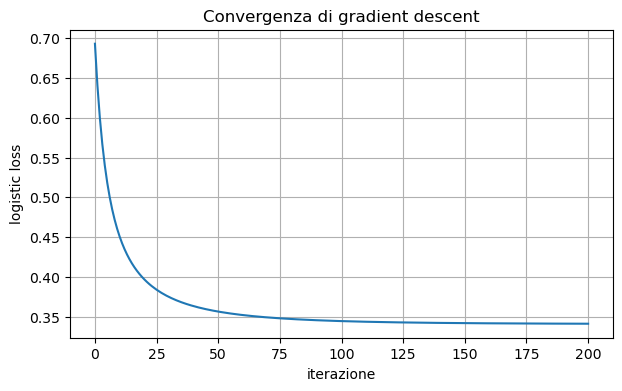

In [ ]:
#TO DO
gamma = ...


T = 200

a_log, history_a, history_loss = gradient_descent_logistic(X, Y, gamma=gamma, T=T, a0=0.0)

plt.plot(history_loss)
plt.xlabel("iterazione")
plt.ylabel("logistic loss")
plt.title("Convergenza di gradient descent")
plt.show()


In [ ]:
# TO DO: rappresentare il rischio empirico con loss logistica valutata sul campione e mostrare che il minimo trovato con GD minimizza la funzione

a_grid = np.linspace(-10, 10, 200)
log_loss_values = ...

loss_at_a_log = ...

plt.plot(...,...., label=r"$\widehat{R}(a)$")
plt.scatter(...,..., color="tab:red", s=80, zorder=3,
            label=r"soluzione GD")
plt.axvline(a_log, color="tab:red", linestyle="--", alpha=0.7)
plt.xlabel("a")
plt.ylabel("Empirical logistic loss")
plt.title("Rischio empirico logistico e minimo trovato con GD")
plt.legend()
plt.show()

# TO DO: scrivere la formula del classificatore corrispondente
y_pred_log = ....